In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
%matplotlib widget
import numpy as np
import pickle
try:
    from gwpy.timeseries import TimeSeries
except:
    ! pip install -q "gwpy==3.0.9"
    ! pip install -q "matplotlib==3.7.3"
    ! pip install -q "astropy==6.1.4"
    from gwpy.timeseries import TimeSeries


def unpickle_me_this(filename: str, absolute_path=False):
    if absolute_path:
        file = open(filename, 'rb')
    else:
        file = open(filename, 'rb')
    data = pickle.load(file)
    file.close()
    return data

def pickle_me_this(filename: str, data_to_pickle: object):
    path = filename + ".pickle"
    file = open(path, 'wb')
    pickle.dump(data_to_pickle, file)
    file.close()


# -- Turn on interactive plotting
plt.ion()

In [5]:
# -- Set a GPS time:
t0 = 1126259462.4    # -- GW150914
#-- Choose detector as H1, L1, or V1

detector = 'H1'
strain = unpickle_me_this("../data/data_pickle_or_hdf5/GW150914_strain.pickle")
data = 1e19 * strain.value

zero_time = 1126259446  # I got this zero time by looking at the caption of the figure produced by strain.plot().
time = np.array(strain.times) - zero_time  # in seconds
onset = t0 - zero_time

length_of_windows = 2

time_domain_in_window, k_length, power_spectrum = unpickle_me_this(
    "../data/data_pickle_or_hdf5/results_from_welch_averaging_data.pickle")

tmp = time_domain_in_window.distances[0]
print(np.sqrt(np.trapz((power_spectrum*(1/tmp)).val**(-1)*tmp, k_length)))

1176.0032964922468


Now, in another file we have gotten the noise power spectrum from the data itself, assuming stationary noise outside of a little data strip where we assume the signal is. We did this by cutting out this signal-containing strip and putting little windows over the rest of the data, such that we could fourier transform those little window strips.

We will now do the inference in a small window centered on where we think the gravitational wave is. This is in order to have a match between the domain the power spectrum is defined over and the domain where the inference happens.

Let's zoom into the strip of data in which we will perform the inference.

In [4]:
signal_strip_idcs = np.where( (time > onset - length_of_windows/2) & ( time < onset + length_of_windows/2) )
signal_strip_time = time[signal_strip_idcs][:-1]  # im taking away the very last element to have a compatible shape with the power spectrum, shouldn't matter
signal_strip_strain = data[signal_strip_idcs][:-1]

approximate_duration_of_merger = 0.04


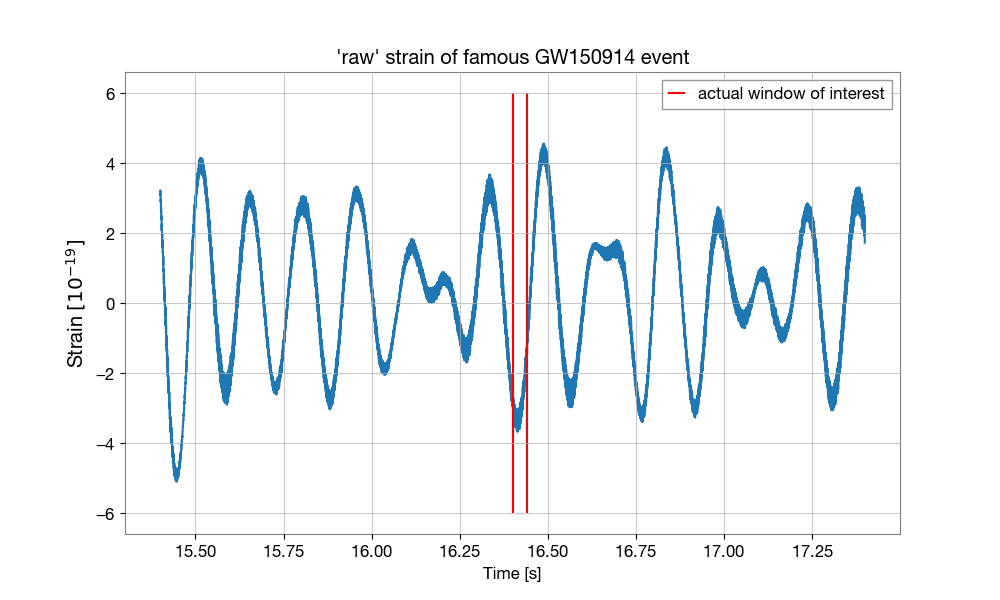

In [9]:
fig = plt.figure(figsize=(10,6))
plt.plot(signal_strip_time, signal_strip_strain)
plt.title("'raw' strain of famous GW150914 event")
plt.ylabel(r"Strain $[10^{-19}]$")
plt.xlabel("Time [s]", fontsize=12)
plt.vlines([onset, onset+approximate_duration_of_merger], -6, 6, color="red", label="actual window of interest")
plt.legend()
plt.show()

Let's also Tukey window this to stay consistent with how we got the noise model...

In [10]:
from scipy.signal.windows import tukey

n_dtps = time_domain_in_window.shape[0]
window_function = tukey(M=n_dtps, alpha=0.1, sym=True)

In [11]:
signal_strip_strain_tapered = signal_strip_strain * window_function

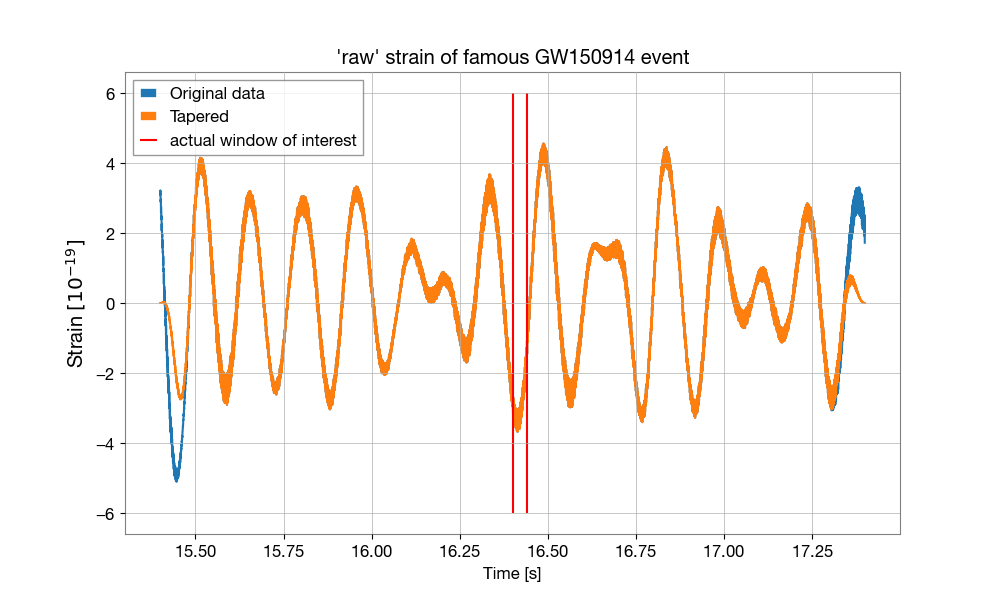

In [12]:
fig2 = plt.figure(figsize=(10,6))
plt.plot(signal_strip_time, signal_strip_strain, label="Original data")
plt.plot(signal_strip_time, signal_strip_strain_tapered, label="Tapered")
plt.title("'raw' strain of famous GW150914 event")
plt.ylabel(r"Strain $[10^{-19}]$")
plt.xlabel("Time [s]", fontsize=12)
plt.vlines([onset, onset+approximate_duration_of_merger], -6, 6, color="red", label="actual window of interest")
plt.legend()
plt.show()

In [4]:
from phase_I.utils.inference_class import *

In [14]:
N = NoiseOperatorFromPowerSpectrum(power_spectrum=power_spectrum, real_space=time_domain_in_window, t0=signal_strip_time[0])

In [15]:
N_inv = N.inverse
N_inv.sanity_check(100)
xi = ift.Field(N.domain, val=np.random.normal(loc=0, scale=1, size=N.domain.shape[0]))
print("Mean residual:", np.mean(xi.val - N(N_inv(xi)).val))
print("WARNING: ONE SANITY CHECK HASN'T PASSED")

Standard deviation b from power spectrum integral:  1175.859732639366
Mean pointwise standard deviation of samples: 2332.7611032070436
Mean residual: -2.7253292645052865e-08


Interesting... Maybe construct ideal data actually first from m=Dj and then do the inference on that data which is then kind of whitened..?


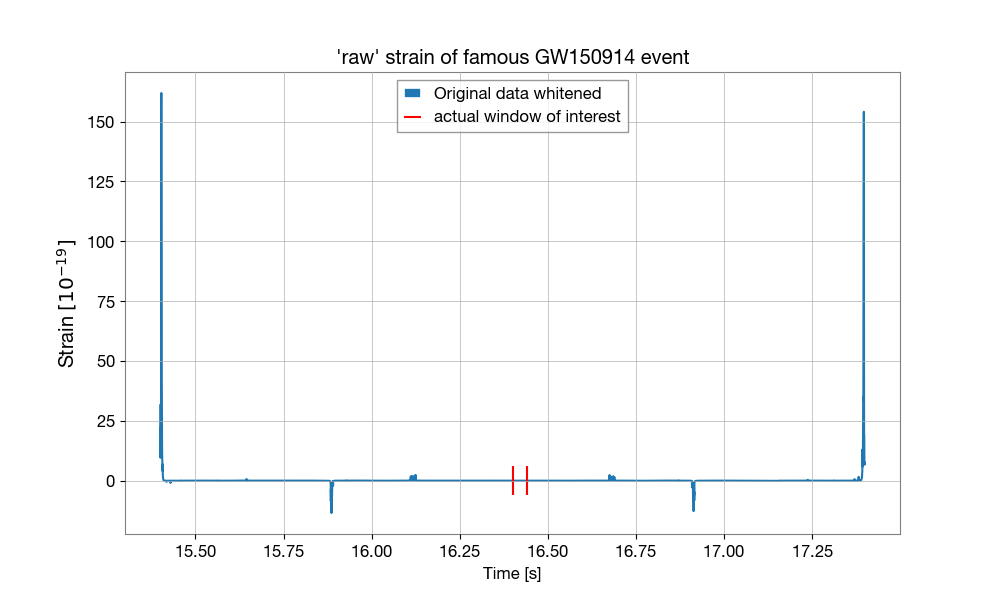

In [16]:
print("Interesting... Maybe construct ideal data actually first from m=Dj and then do the inference on that data which is then kind of whitened..?")
plt.figure(figsize=(10,6))
plt.plot(signal_strip_time, signal_strip_strain/(N_inv.N_sqrt_fourier._ldiag), label="Original data whitened")
plt.title("'raw' strain of famous GW150914 event")
plt.ylabel(r"Strain $[10^{-19}]$")
plt.xlabel("Time [s]", fontsize=12)
plt.vlines([onset, onset+approximate_duration_of_merger], -6, 6, color="red", label="actual window of interest")
plt.legend()
plt.show()

In [17]:

inference_scheme = ExecuteRGSpaceKL(
    custom_data_space = N.domain[0],
    discrete_time=signal_strip_time,
    d=signal_strip_strain_tapered,
    cfm_model_name="GW CFM ",
    kl_minimizations=5,
    fluct=(8, 1),
    llslope=(-4, 0.5),
    gaussian_noise_level=None,
    custom_noise_operator=N,
    out_dir_name="outs/GW_inference_out_2"
)

Offset amplitude: 8.28E-17 ± 5.69E-17
Total fluctuation amplitude: 7.99E+00 ± 1.00E+00


Number of datapoints:  8191
Constructing RGspace of this number of points:  16382  (not extended)
Based on sampling rate, length and shape of domain, keeping  8191  points of continuous signal.


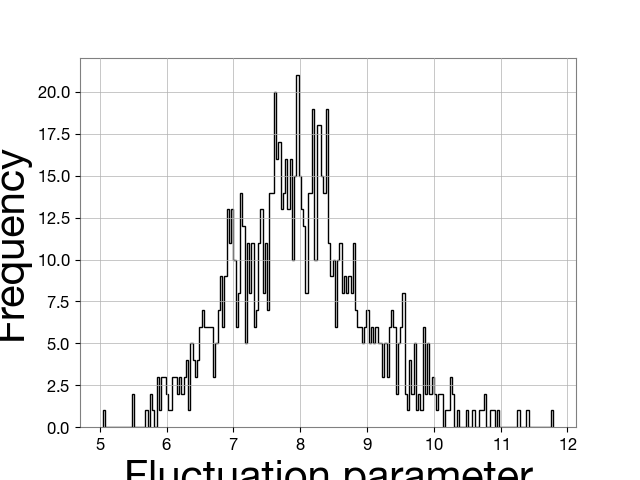

In [18]:
plt.figure()
inference_scheme.plot_prior_fluctuations_distribution()

[<nifty8.Field>]

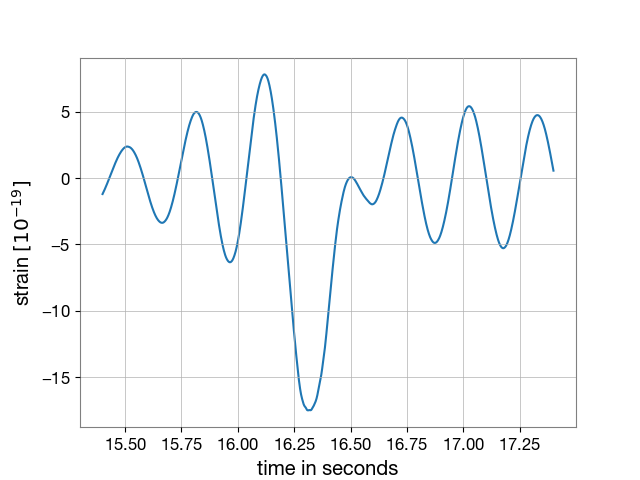

In [19]:
plt.figure()
inference_scheme.plot_prior_samples(1)


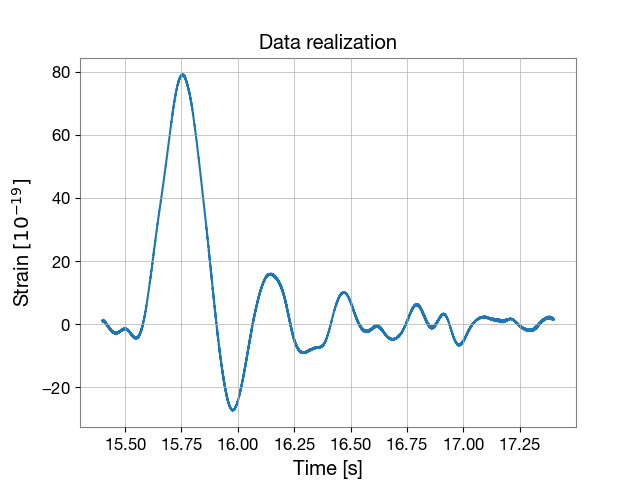

In [20]:
plt.figure()
plt.xlabel("Time [s]")
plt.ylabel("Strain $[10^{-19}]$")
plt.title("Data realization")
inference_scheme.plot_data_realizations(1)

In [21]:
inference_scheme.run()

Creating Gaussian likelihood...
Created Gaussian likelihood, running KL.
Posterior samples saved. Analyze via class.plot_posterior()


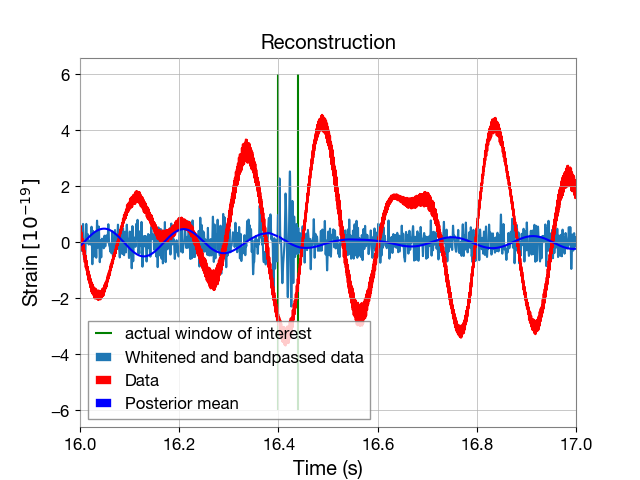

In [27]:
plt.figure()
plt.vlines([onset, onset+approximate_duration_of_merger], -6, 6, color="green", label="actual window of interest")

zero_time = 1126259446  # I got this zero time by looking at the caption of the figure produced by strain.plot().
times = np.array(strain.times) - zero_time  # in seconds
wh = strain.whiten(fftlength=1)
bp = wh.bandpass(30, 400)
plt.plot(times, bp.value, label="Whitened and bandpassed data")
plt.xlim(16, 17)
inference_scheme.plot_posterior(plot_signal_space=True, plot_with_variance=False)

In [23]:
def custom_whitening_procedure(d, harmonic_transform, noise_op: NoiseOperatorFromPowerSpectrum):
    """

    :param d:                           The data (np.array) to analyze.
    :param harmonic_transform:
    :param noise_op:                The real space noise operator.
    :return:
    """

    data_space = noise_op.domain
    data_field = ift.Field(data_space, val=d)

    P_n_sqrt_inv = noise_op.inverse.N_sqrt_fourier._ldiag

    ht = harmonic_transform
    num_of_pixels = len(d)
    s_vol = ht.domain[0].distances[0]
    d_fourier = ht(data_field)


    d_fourier_w = ift.Field(domain=ht.target, val=d_fourier.val * P_n_sqrt_inv)

    return ht.adjoint(d_fourier_w) / (num_of_pixels * s_vol**2)

my_whitened_data = custom_whitening_procedure(d=signal_strip_strain_tapered, harmonic_transform=ift.HartleyOperator(time_domain_in_window),
                                              noise_op=N)

(15.400146484375, 17.399658203125)

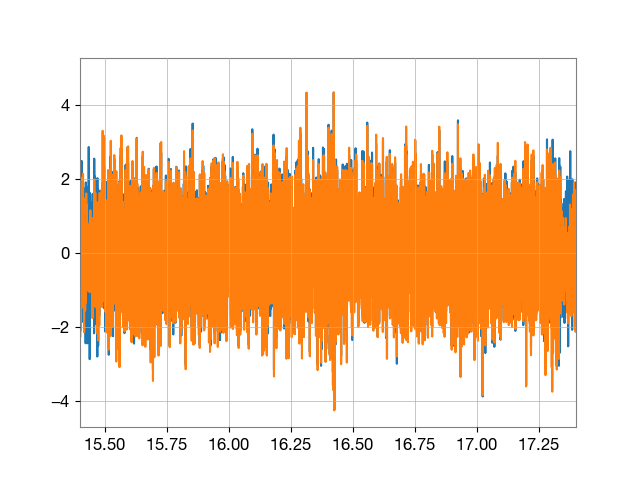

In [30]:
plt.figure()
plt.plot(times, wh.value, label="their whitened data")
plt.plot(signal_strip_time, my_whitened_data.val, label="Whitened data")
plt.xlim(min(signal_strip_time), max(signal_strip_time))